In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **Upload DataSet**

In [3]:
players_stat = pd.read_csv("/content/Players_round_by_round_stat_raw.csv")

# **Players_stat Overview**

In [4]:
print("Shape:", players_stat.shape)
print("Rows:", players_stat.shape[0])
print("Columns:", players_stat.shape[1])

Shape: (274089, 36)
Rows: 274089
Columns: 36


In [5]:
players_stat.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


In [6]:
players_stat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274089 non-null  int64  
 1   team                       274089 non-null  object 
 2   year                       274089 non-null  int64  
 3   career_game_count          274089 non-null  int64  
 4   opponent                   274089 non-null  object 
 5   round                      274089 non-null  object 
 6   result                     274089 non-null  object 
 7   jersey_num                 274089 non-null  int64  
 8   kicks                      272789 non-null  float64
 9   marks                      266038 non-null  float64
 10  handballs                  269656 non-null  float64
 11  disposals                  265636 non-null  float64
 12  goals                      199352 non-null  float64
 13  behinds                    19

**Missing Values and Duplicates**

In [7]:
players_stat.isnull().sum()

,0
id,0
team,0
year,0
career_game_count,0
opponent,0
round,0
result,0
jersey_num,0
kicks,1300
marks,8051


In [8]:
print("Duplicate rows:", players_stat.duplicated().sum())

Duplicate rows: 10


# **Players_stat Cleaning**

In [9]:
# remove duplicate rows
players_stat = players_stat.drop_duplicates()

In [10]:
# Drop column Score
players_stat = players_stat.drop(columns=['score'])

In [11]:
# Fill missing numeric match statistics with 0
stat_columns = [
    'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds',
    'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances',
    'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
    'contested_possessions', 'uncontested_possessions', 'contested_marks',
    'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist',
    'percentage_of_game_played'
]
players_stat[stat_columns] = players_stat[stat_columns].fillna(0)

In [12]:
# List of all count columns that should be integers
int_columns = [
    'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds',
    'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances',
    'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
    'contested_possessions', 'uncontested_possessions', 'contested_marks',
    'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist'
]
# Convert float values to integers
players_stat[int_columns] = players_stat[int_columns].astype(int)

In [13]:
# Convert match_date column to datetime format
players_stat['match_date'] = pd.to_datetime(players_stat['match_date'])

In [14]:
# Summary Verification
print("Cleaning Complete")
print("New Shape:", players_stat.shape)
print("Remaining Null Values:", players_stat.isnull().sum().sum())
print("Duplicate Rows Remaining:", players_stat.duplicated().sum())

Cleaning Complete
New Shape: (274079, 35)
Remaining Null Values: 0
Duplicate Rows Remaining: 0


# **Convert Cleaned Data to CSV Format**

In [15]:
# Save the cleaned DataFrame to a new CSV file
players_stat.to_csv('Players_round_by_round_stat_cleaned.csv', index=False)
print("Cleaned data successfully saved to CSV!")

Cleaned data successfully saved to CSV!


# **Last Verification**

In [16]:
# 1. Check total number of missing (null) values
total_nulls = players_stat.isnull().sum().sum()
print("Total Missing Values:", total_nulls)

# 2. Check missing values column by column
print("\nMissing Values Per Column:")
print(players_stat.isnull().sum())

# 3. Check total number of duplicate rows
total_duplicates = players_stat.duplicated().sum()
print("\nTotal Duplicate Rows:", total_duplicates)

Total Missing Values: 0

Missing Values Per Column:
id                           0
team                         0
year                         0
career_game_count            0
opponent                     0
round                        0
result                       0
jersey_num                   0
kicks                        0
marks                        0
handballs                    0
disposals                    0
goals                        0
behinds                      0
hit_outs                     0
tackles                      0
rebound_50s                  0
inside_50s                   0
clearances                   0
clangers                     0
free_kicks_for               0
free_kicks_against           0
brownlow_votes               0
contested_possessions        0
uncontested_possessions      0
contested_marks              0
marks_inside_50              0
one_percenters               0
bounces                      0
goal_assist                  0
percentage_of_game

# **Actual Implementation Task After cleaning the DataSet**

In [17]:
# Load player information
players_info = pd.read_csv("cleaned_players_info.csv")

# Load full-season statistics
seasonal_stats = pd.read_csv("cleaned_Seasonal_Stats.csv")

# Load match-by-match statistics
round_stats = pd.read_csv("Players_round_by_round_stat_cleaned.csv")

print("Players Info:", players_info.shape)
print("Seasonal Stats:", seasonal_stats.shape)
print("Round Stats:", round_stats.shape)

Players Info: (2843, 16)
Seasonal Stats: (25471, 54)
Round Stats: (274079, 35)


# **Merged Datasets to Perform Further Tasks**

In [18]:
# Rename ID so it matches the other datasets
players_info = players_info.rename(columns={"id": "player_id"})

# Merge player information with seasonal statistics
seasonal_merged = pd.merge(seasonal_stats,players_info,on="player_id",how="left")

# Merge player information with round-by-round statistics
round_merged = pd.merge(round_stats,players_info,on="player_id",how="left")

print("Seasonal Merged Data:", seasonal_merged.shape)
print("Round Merged Data:", round_merged.shape)

seasonal_merged.head()

Seasonal Merged Data: (25471, 69)
Round Merged Data: (274079, 50)


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261.0,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
1,43261.0,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
2,43261.0,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
3,43261.0,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
4,43262.0,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,2002-03-30,17.0,2020-10-24,36.0,182.0,87.0,No Image,https://afltables.com/afl/stats/players/G/Gary...,Unknown,"{Geelong Cats,Gold Coast Suns}"


# **Select 2024 Season**

In [19]:
# Select 2024 regular-season data
season_2024 = seasonal_merged[
    (seasonal_merged["year"] == 2024) &
    (seasonal_merged["is_finals"] == False)
].copy()

# Select 2024 round-by-round data
round_2024 = round_merged[
    round_merged["year"] == 2024
].copy()

print("2024 Seasonal Data:", season_2024.shape)
print("2024 Round Data:", round_2024.shape)

2024 Seasonal Data: (658, 69)
2024 Round Data: (9936, 50)


# **Feature Engineering**

In [21]:
# 1. Goals scored per game
season_2024["Goals_Per_Game"] = (season_2024["goals"] / season_2024["games_played"])

# 2. Fantasy points per game
season_2024["Fantasy_Per_Game"] = (season_2024["total_fantasy_points"] / season_2024["games_played"])

# 3. Disposal efficiency
season_2024["Disposal_Efficiency"] = ((season_2024["disposals"] - season_2024["clangers"])/ season_2024["disposals"]) * 100

# Replace missing values
season_2024["Disposal_Efficiency"] = (season_2024["Disposal_Efficiency"].fillna(0))

# 4. Tackles per game
season_2024["Tackles_Per_Game"] = (season_2024["tackles"] / season_2024["games_played"])

# 5. Clearances per game
season_2024["Clearances_Per_Game"] = (season_2024["clearances"] / season_2024["games_played"])

# 6. Score contribution per game
season_2024["Score_Per_Game"] = ((season_2024["goals"] * 6 + season_2024["behinds"])/ season_2024["games_played"])

# 7. Contested possessions per game
season_2024["Contested_Per_Game"] = (season_2024["contested_possessions"]/ season_2024["games_played"])

# Display new features
season_2024[[
        "player_name",
        "Goals_Per_Game",
        "Fantasy_Per_Game",
        "Disposal_Efficiency",
        "Tackles_Per_Game",
        "Clearances_Per_Game",
        "Score_Per_Game",
        "Contested_Per_Game"
    ]].head()

,player_name,Goals_Per_Game,Fantasy_Per_Game,Disposal_Efficiency,Tackles_Per_Game,Clearances_Per_Game,Score_Per_Game,Contested_Per_Game
57,Blake Acres,0.545455,88.590909,84.928717,2.909091,1.772727,3.818182,7.363636
94,Taylor Adams,0.473684,67.526316,82.208589,3.578947,2.578947,3.157895,7.684211
127,Ben Ainsworth,0.941176,65.058824,86.792453,1.117647,0.470588,6.176471,3.294118
145,James Aish,0.150000,65.150000,90.855457,1.500000,0.900000,1.100000,3.150000
148,Leek Aleer,0.375000,42.750000,81.707317,2.250000,0.125000,2.625000,4.625000


# **Task 1 : Create Performance Index & Top 10 Most Valueable Players**

In [22]:
# Keep players who played at least 10 games
valuable_players = season_2024[season_2024["games_played"] >= 10].copy()

# Convert each statistic into a score out of 100
valuable_players["Disposals_Score"] = (valuable_players["avg_disposals"]/ valuable_players["avg_disposals"].max()) * 100

valuable_players["Goals_Score"] = (valuable_players["avg_goals"]/ valuable_players["avg_goals"].max()) * 100

valuable_players["Tackles_Score"] = (valuable_players["avg_tackles"]/ valuable_players["avg_tackles"].max()) * 100

valuable_players["Clearances_Score"] = (valuable_players["avg_clearances"]/ valuable_players["avg_clearances"].max()) * 100

valuable_players["Fantasy_Score"] = (valuable_players["Fantasy_Per_Game"]/ valuable_players["Fantasy_Per_Game"].max()) * 100

valuable_players["Efficiency_Score"] = (valuable_players["Disposal_Efficiency"]/ valuable_players["Disposal_Efficiency"].max()) * 100

# Calculate overall Performance Index
valuable_players["Performance_Index"] = (
    valuable_players["Disposals_Score"] * 0.20 +
    valuable_players["Goals_Score"] * 0.15 +
    valuable_players["Tackles_Score"] * 0.15 +
    valuable_players["Clearances_Score"] * 0.15 +
    valuable_players["Fantasy_Score"] * 0.25 +
    valuable_players["Efficiency_Score"] * 0.10
)

# Rank players and select Top 10
top_10_players = valuable_players.sort_values("Performance_Index",ascending=False).head(10)

top_10_players[[
        "player_name",
        "team",
        "games_played",
        "avg_disposals",
        "avg_goals",
        "avg_tackles",
        "avg_clearances",
        "Fantasy_Per_Game",
        "Disposal_Efficiency",
        "Performance_Index"
    ]].round(2)

,player_name,team,games_played,avg_disposals,avg_goals,avg_tackles,avg_clearances,Fantasy_Per_Game,Disposal_Efficiency,Performance_Index
10335,Caleb Serong,Fremantle Dockers,23,29.4,1.4,5.0,7.6,104.04,91.42,80.98
24219,Marcus Bontempelli,Western Bulldogs,23,26.1,1.9,5.5,6.4,107.35,87.33,80.38
2218,Patrick Cripps,Carlton Blues,23,28.7,1.3,5.5,8.1,100.04,82.75,80.12
21036,Adam Treloar,western bulldogs,22,31.7,1.4,4.8,5.8,110.00,87.95,79.62
22220,Nick Daicos,COLLINGWOOD MAGPIES,23,30.7,1.4,3.8,7.7,104.70,84.40,79.13
8429,Lachie Neale,Brisbane Lions,22,29.5,1.6,3.9,7.5,101.14,88.92,78.91
11983,Sam Walsh,Carlton Blues,19,28.4,1.3,6.8,5.1,106.11,85.74,78.43
11005,Jack Steele,St Kilda Saints,23,24.2,1.6,7.3,5.0,106.61,88.33,78.42
9929,Matt Rowell,GOLD COAST SUNS,23,23.4,1.1,8.0,7.1,93.74,81.97,77.18
4656,Isaac Heeney,Sydney Swans,21,25.4,1.8,4.8,5.9,105.19,86.33,76.64


# **Visualization 1 : Top 10 Players**

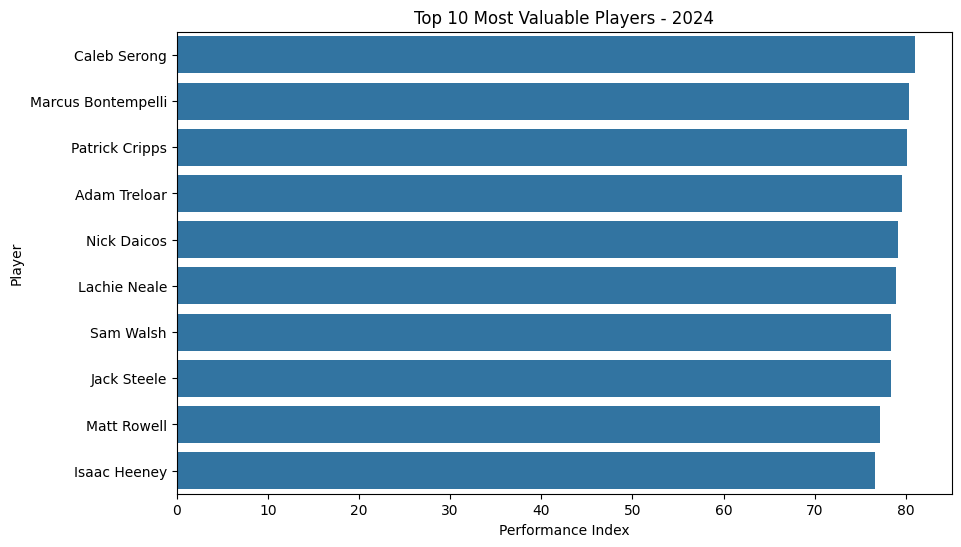

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_10_players,x="Performance_Index",y="player_name")
plt.title("Top 10 Most Valuable Players - 2024")
plt.xlabel("Performance Index")
plt.ylabel("Player")
plt.show()

# **Task 2 : Finding Most Consistent Players**

In [24]:
# Sort games by player and date
round_2024 = round_2024.sort_values(["player_name", "match_date"])

# Remove games where player played less than 50% of the match
round_2024 = round_2024[round_2024["percentage_of_game_played"] >= 50].copy()

# Calculate average and variation in fantasy points
consistency = round_2024.groupby("player_name").agg(
    Games=("fantasy_points", "count"),
    Average_Fantasy=("fantasy_points", "mean"),
    Fantasy_STD=("fantasy_points", "std")
).reset_index()

# Keep players with enough games
consistency = consistency[consistency["Games"] >= 10].copy()

# Lower score means more consistent
consistency["Consistency_Score"] = (consistency["Fantasy_STD"]/ consistency["Average_Fantasy"]) * 100

# Select 10 most consistent players
most_consistent = consistency.sort_values("Consistency_Score",ascending=True).head(10)
most_consistent.round(2)

,player_name,Games,Average_Fantasy,Fantasy_STD,Consistency_Score
542,Sam Berry,11,71.82,7.95,11.07
282,Jacob Hopper,11,83.64,9.49,11.35
550,Sam Durham,21,84.71,12.33,14.55
455,Max Holmes,25,94.28,14.07,14.92
420,Luke Davies-Uniacke,23,95.87,14.45,15.08
193,Dion Prestia,12,76.67,11.73,15.30
471,Nasiah Wanganeen-Milera,22,97.73,15.48,15.84
301,Jake Soligo,21,81.38,12.98,15.95
441,Matt Crouch,15,101.93,16.31,16.00
540,Ryley Sanders,12,69.50,11.16,16.05


# **Visualization 2 : Consistency**

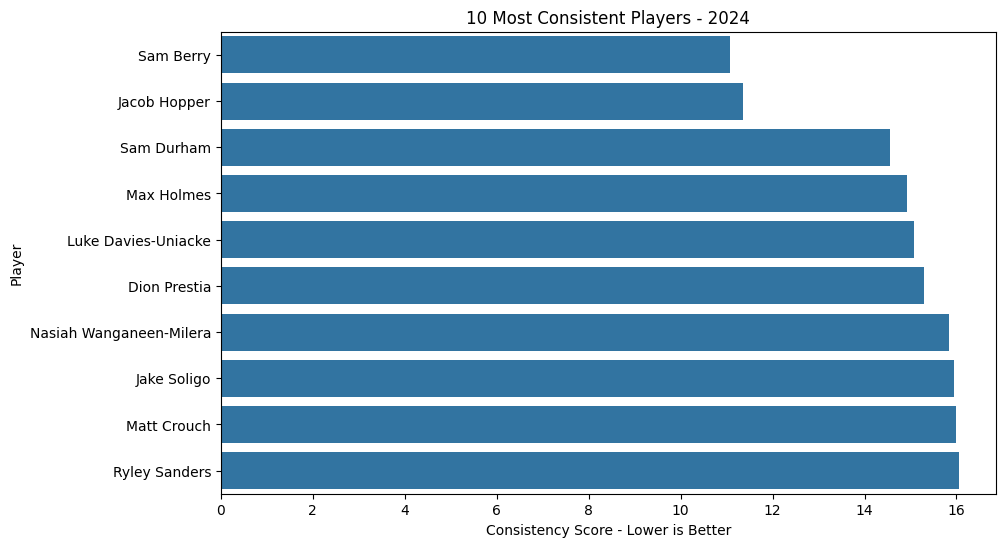

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(data=most_consistent,x="Consistency_Score",y="player_name")
plt.title("10 Most Consistent Players - 2024")
plt.xlabel("Consistency Score - Lower is Better")
plt.ylabel("Player")
plt.show()

# **Visualization 3 : Consistency vs Performance**

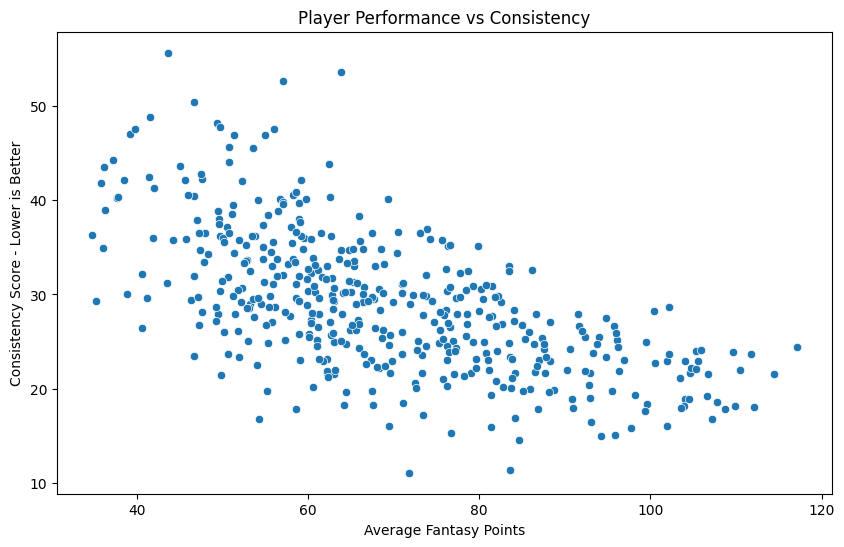

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=consistency,x="Average_Fantasy",y="Consistency_Score")
plt.title("Player Performance vs Consistency")
plt.xlabel("Average Fantasy Points")
plt.ylabel("Consistency Score - Lower is Better")
plt.show()

# **Task 3 : Performance Trends**

In [27]:
# Give each game a number for every player
round_2024["Game_Number"] = (round_2024.groupby("player_name").cumcount() + 1)

# Count total games for every player
round_2024["Total_Games"] = (round_2024.groupby("player_name")["player_name"].transform("count"))

# Start by calling every game Second Half
round_2024["Season_Half"] = "Second Half"

# Change first half games to First Half
round_2024.loc[round_2024["Game_Number"] <= round_2024["Total_Games"] / 2,"Season_Half"] = "First Half"

# Calculate average fantasy points for each half
trend_data = round_2024.groupby(["player_name", "Season_Half"])["fantasy_points"].mean().reset_index()

# Put both halves into separate columns
trend_pivot = trend_data.pivot(index="player_name",columns="Season_Half",values="fantasy_points").reset_index()

# Calculate performance change
trend_pivot["Performance_Change"] = (trend_pivot["Second Half"]- trend_pivot["First Half"])

# Players who improved
top_improved = trend_pivot.sort_values("Performance_Change",ascending=False).head(10)

# Players who declined
top_declined = trend_pivot.sort_values("Performance_Change",ascending=True).head(10)

print("TOP IMPROVED PLAYERS")
print(top_improved.round(2))

print("\nTOP DECLINED PLAYERS")
print(top_declined.round(2))

TOP IMPROVED PLAYERS
Season_Half        player_name  First Half  Second Half  Performance_Change
205               Edward Allan       25.00        87.00               62.00
554          Sam Powell-Pepper       41.00        80.00               39.00
164                Cooper Lord       51.00        88.00               37.00
531                Rory Atkins       32.00        67.00               35.00
292          Jaidyn Stephenson       40.40        74.33               33.93
68                 Andrew Gaff       44.00        76.50               32.50
181                 Darcy Fort       47.00        79.50               32.50
20                Hugh Davies         0.00        32.00               32.00
50              Will Ashcroft        71.17        99.86               28.69
269                Jack Martin       31.00        56.00               25.00

TOP DECLINED PLAYERS
Season_Half        player_name  First Half  Second Half  Performance_Change
466              Mitch Knevitt       88.00   

# **Visualization 4: Improved Players**

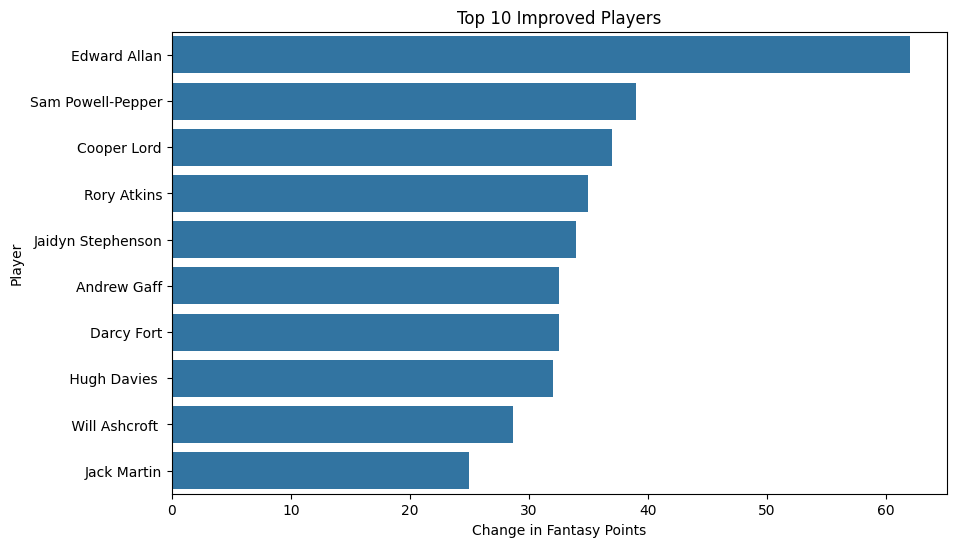

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_improved,x="Performance_Change",y="player_name")
plt.title("Top 10 Improved Players")
plt.xlabel("Change in Fantasy Points")
plt.ylabel("Player")
plt.show()

# **Visualization 5: Declined Players**

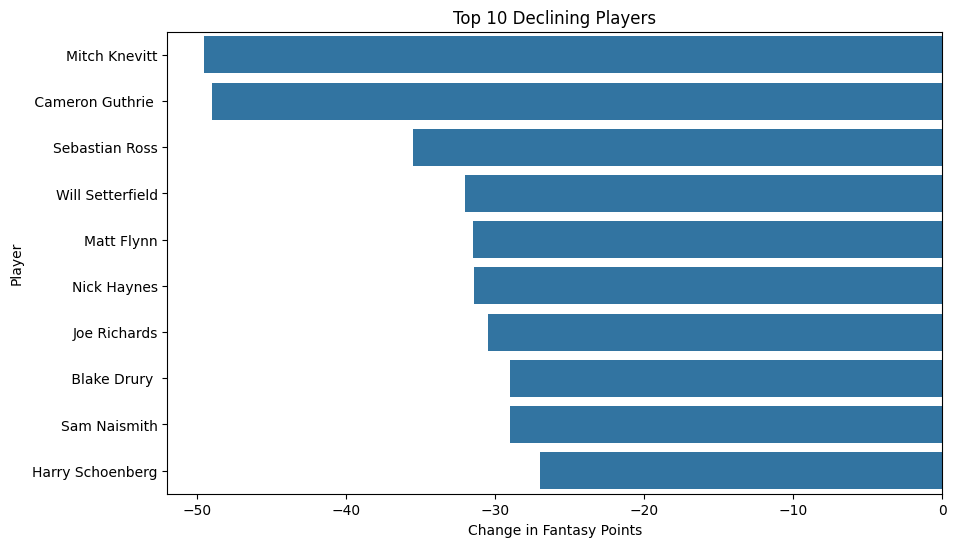

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_declined,x="Performance_Change",y="player_name")
plt.title("Top 10 Declining Players")
plt.xlabel("Change in Fantasy Points")
plt.ylabel("Player")
plt.show()

# **Task 4: Team Performance Analysis**

In [30]:
# Calculate team-level averages
team_performance = valuable_players.groupby("team").agg(
    Average_Performance_Index=("Performance_Index", "mean"),
    Average_Fantasy_Per_Game=("Fantasy_Per_Game", "mean"),
    Average_Disposal_Efficiency=("Disposal_Efficiency", "mean"),
    Average_Goals_Per_Game=("Goals_Per_Game", "mean"),
    Number_of_Players=("player_name", "count")
).reset_index()

# Convert metrics to scores out of 100
team_performance["Performance_Score"] = (team_performance["Average_Performance_Index"]/ team_performance["Average_Performance_Index"].max()) * 100

team_performance["Fantasy_Score"] = (team_performance["Average_Fantasy_Per_Game"]/ team_performance["Average_Fantasy_Per_Game"].max()) * 100

team_performance["Efficiency_Score"] = (team_performance["Average_Disposal_Efficiency"]/ team_performance["Average_Disposal_Efficiency"].max()) * 100

team_performance["Goals_Score"] = (team_performance["Average_Goals_Per_Game"]/ team_performance["Average_Goals_Per_Game"].max()) * 100

# Calculate final team score
team_performance["Team_Performance_Score"] = (
    team_performance["Performance_Score"] * 0.40 +
    team_performance["Fantasy_Score"] * 0.30 +
    team_performance["Efficiency_Score"] * 0.15 +
    team_performance["Goals_Score"] * 0.15
)

# Rank teams
team_performance = team_performance.sort_values("Team_Performance_Score",ascending=False)
team_performance["Team_Rank"] = range(1,len(team_performance) + 1)

# Final team ranking
team_performance[[
        "Team_Rank",
        "team",
        "Average_Performance_Index",
        "Average_Fantasy_Per_Game",
        "Average_Disposal_Efficiency",
        "Average_Goals_Per_Game",
        "Team_Performance_Score"
    ]].round(2)

,Team_Rank,team,Average_Performance_Index,Average_Fantasy_Per_Game,Average_Disposal_Efficiency,Average_Goals_Per_Game,Team_Performance_Score
14,1,St Kilda Saints,74.28,117.09,76.52,0.65,87.55
32,2,COLLINGWOOD MAGPIES,71.35,93.89,83.10,0.74,81.79
63,3,brisbane lions,67.86,97.35,86.34,0.74,81.32
16,4,Western Bulldogs,61.92,84.15,88.29,0.75,75.10
15,5,Sydney Swans,69.65,84.67,83.83,0.24,74.60
...,...,...,...,...,...,...,...
12,75,RICHMOND TIGERS,37.62,44.71,82.32,0.29,47.25
26,76,western bulldogs,35.20,51.35,83.61,0.15,46.76
13,77,SYDNEY SWANS,34.99,38.31,74.51,0.62,45.67
50,78,PORT ADELAIDE POWER,31.35,37.10,85.71,0.40,43.39


# **Visualization 6: Team Ranking**

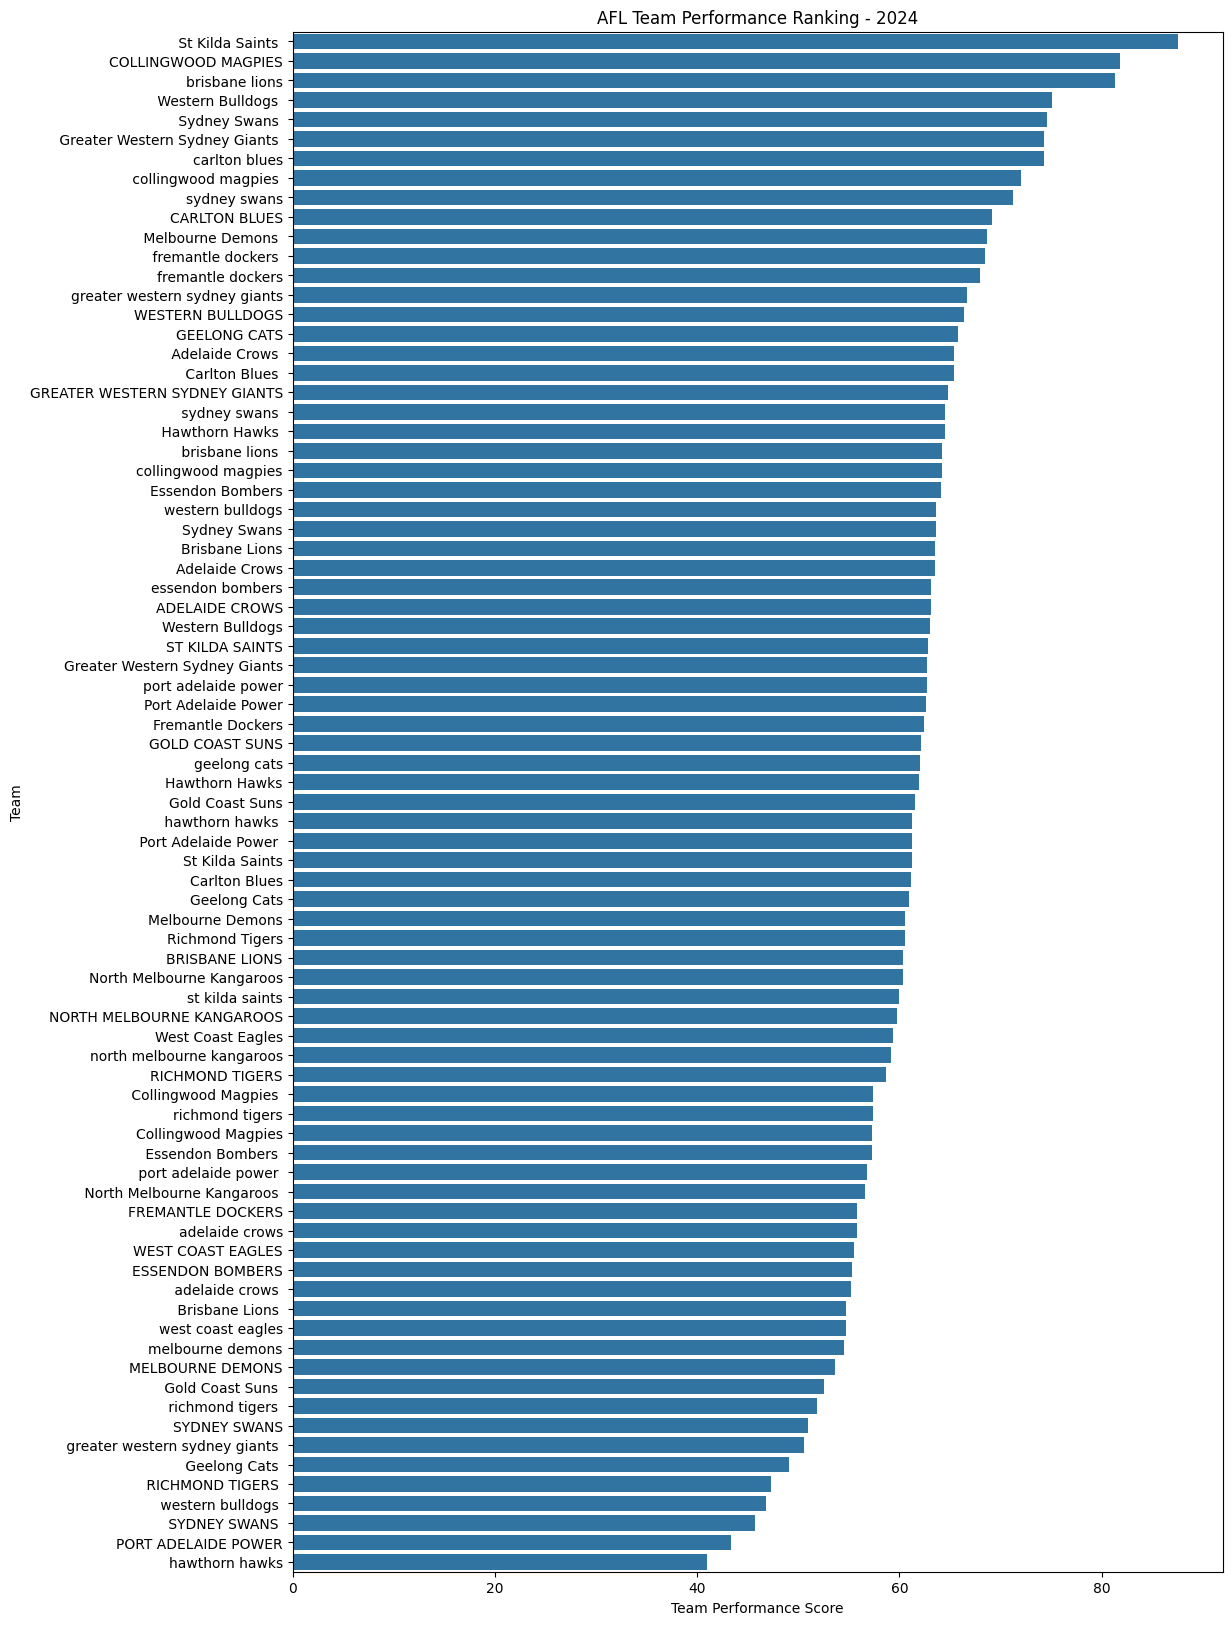

In [35]:
plt.figure(figsize=(12, 20))
sns.barplot(data=team_performance,x="Team_Performance_Score",y="team")
plt.title("AFL Team Performance Ranking - 2024")
plt.xlabel("Team Performance Score")
plt.ylabel("Team")
plt.show()

# **Task 5: Final Recruitment Recommendations**

In [36]:
# Add consistency information
recruitment_data = pd.merge(valuable_players,consistency[["player_name", "Games", "Average_Fantasy", "Consistency_Score"]],on="player_name",how="left")

# Add performance trend
recruitment_data = pd.merge(recruitment_data,trend_pivot[["player_name", "Performance_Change"]],on="player_name",how="left")

# Fill missing values
recruitment_data["Consistency_Score"] = (recruitment_data["Consistency_Score"].fillna(recruitment_data["Consistency_Score"].median()))

recruitment_data["Performance_Change"] = (recruitment_data["Performance_Change"].fillna(0))

# Performance score
recruitment_data["Recruitment_Performance"] = (recruitment_data["Performance_Index"]/ recruitment_data["Performance_Index"].max()) * 100

# Reverse consistency because lower consistency score is better
recruitment_data["Recruitment_Consistency"] = (1 -recruitment_data["Consistency_Score"]/ recruitment_data["Consistency_Score"].max()) * 100

# Convert trend into a 0-100 score
recruitment_data["Recruitment_Trend"] = (
    (recruitment_data["Performance_Change"]
     - recruitment_data["Performance_Change"].min())/
    (recruitment_data["Performance_Change"].max()
     - recruitment_data["Performance_Change"].min())) * 100

# Final recruitment score
recruitment_data["Recruitment_Score"] = (
    recruitment_data["Recruitment_Performance"] * 0.50 +
    recruitment_data["Recruitment_Consistency"] * 0.25 +
    recruitment_data["Recruitment_Trend"] * 0.25
    )

# Select top 5
top_5_recruits = recruitment_data.sort_values("Recruitment_Score",ascending=False).head(5)

top_5_recruits[[
        "player_name",
        "team",
        "games_played",
        "Performance_Index",
        "Fantasy_Per_Game",
        "Consistency_Score",
        "Performance_Change",
        "Recruitment_Score"
    ]].round(2)

,player_name,team,games_played,Performance_Index,Fantasy_Per_Game,Consistency_Score,Performance_Change,Recruitment_Score
339,Tristan Xerri,North Melbourne Kangaroos,23,75.28,114.48,21.57,22.87,82.81
70,Patrick Cripps,Carlton Blues,23,80.12,100.04,18.39,2.42,79.87
385,Adam Treloar,western bulldogs,22,79.62,110.00,18.19,1.76,79.42
71,Matt Crouch,Adelaide Crows,15,74.42,101.93,16.00,4.70,78.24
364,Tom Green,greater western sydney giants,23,73.99,99.91,17.96,6.42,77.72


# **Visualization 7: Top 5 Recruitment Players**

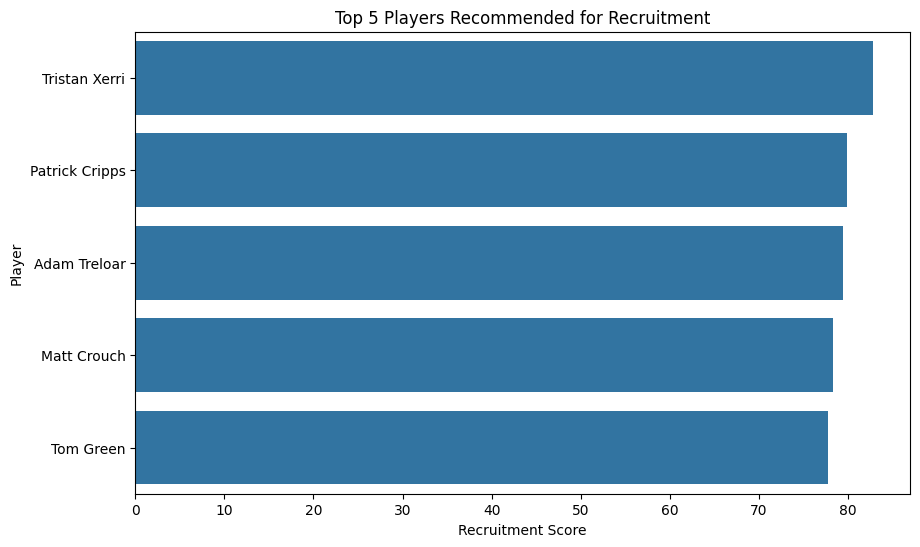

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_5_recruits,x="Recruitment_Score",y="player_name")
plt.title("Top 5 Players Recommended for Recruitment")
plt.xlabel("Recruitment Score")
plt.ylabel("Player")

plt.show()

# **Visualization 8: Recruitment Evidence**

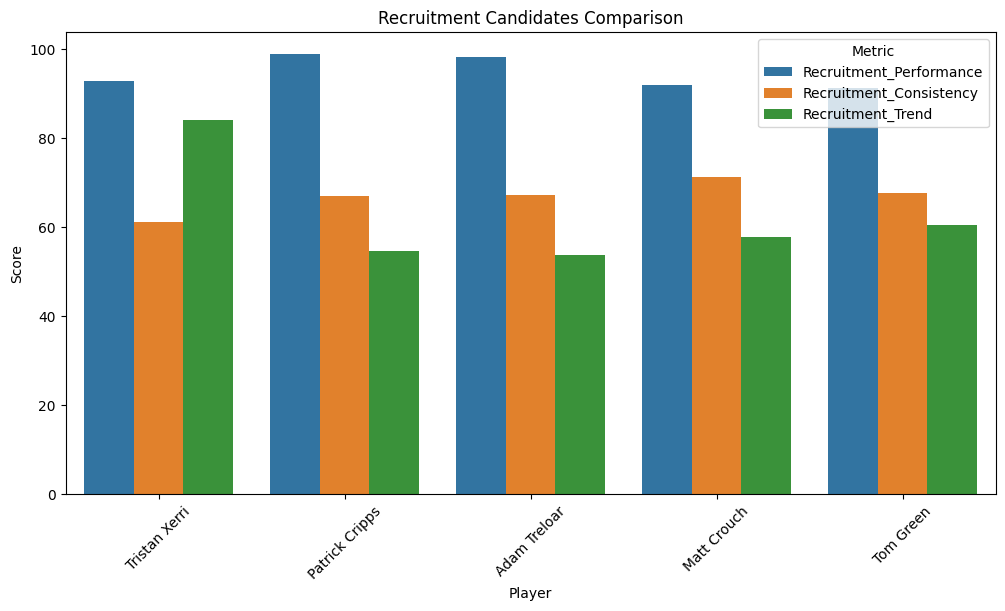

In [38]:
# Compare the three main recruitment factors
recruitment_chart = top_5_recruits[[
        "player_name",
        "Recruitment_Performance",
        "Recruitment_Consistency",
        "Recruitment_Trend"
    ]].melt(id_vars="player_name",var_name="Metric",value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=recruitment_chart,x="player_name",y="Score",hue="Metric")
plt.title("Recruitment Candidates Comparison")
plt.xlabel("Player")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# **Final Recommendation Summary**

In [39]:
# Create final recommendation table
final_recommendations = top_5_recruits[[
        "player_name",
        "team",
        "Performance_Index",
        "Fantasy_Per_Game",
        "Disposal_Efficiency",
        "Consistency_Score",
        "Performance_Change",
        "Recruitment_Score"
    ]].copy()

# Add ranking
final_recommendations.insert(0,"Rank",range(1, 6))

# Round values
final_recommendations = final_recommendations.round(2)
final_recommendations

,Rank,player_name,team,Performance_Index,Fantasy_Per_Game,Disposal_Efficiency,Consistency_Score,Performance_Change,Recruitment_Score
339,1,Tristan Xerri,North Melbourne Kangaroos,75.28,114.48,72.57,21.57,22.87,82.81
70,2,Patrick Cripps,Carlton Blues,80.12,100.04,82.75,18.39,2.42,79.87
385,3,Adam Treloar,western bulldogs,79.62,110.00,87.95,18.19,1.76,79.42
71,4,Matt Crouch,Adelaide Crows,74.42,101.93,88.20,16.00,4.70,78.24
364,5,Tom Green,greater western sydney giants,73.99,99.91,83.55,17.96,6.42,77.72


# **Bussiness Insights**

In [40]:
# Business Insights

print("1. Top Player:")
print("The player with the highest Performance Index demonstrated the strongest overall combination of scoring, disposals, tackles, clearances and fantasy performance.")

print("\n2. Player Involvement:")
print("High disposal numbers indicate strong involvement in team play, but disposals alone were not enough to determine the best player.")

print("\n3. Scoring:")
print("Goals per game helped identify players who provide strong direct attacking contribution.")

print("\n4. Defensive Value:")
print("Tackles per game highlighted players who contribute defensively in addition to attacking performance.")

print("\n5. Stoppage Performance:")
print("Clearances per game identified players who are effective at winning possession from stoppages.")

print("\n6. Efficiency:")
print("Disposal Efficiency helped distinguish players who use their possessions effectively.")

print("\n7. Consistency:")
print("Players with lower Consistency Scores showed more stable fantasy performance throughout the season.")

print("\n8. Improvement:")
print("Players with positive Performance Change improved their fantasy output during the second half of the season.")

print("\n9. Decline:")
print("Players with negative Performance Change experienced a reduction in average fantasy performance during the second half.")

print("\n10. Team Quality:")
print("Teams with higher Team Performance Scores had stronger overall player performance.")

print("\n11. Recruitment:")
print("The recruitment model considers current performance, consistency and performance trend instead of relying on only one statistic.")

print("\n12. Recruitment Potential:")
print("Players ranking highly across all three recruitment factors represent stronger all-round recruitment opportunities.")

1. Top Player:
The player with the highest Performance Index demonstrated the strongest overall combination of scoring, disposals, tackles, clearances and fantasy performance.

2. Player Involvement:
High disposal numbers indicate strong involvement in team play, but disposals alone were not enough to determine the best player.

3. Scoring:
Goals per game helped identify players who provide strong direct attacking contribution.

4. Defensive Value:
Tackles per game highlighted players who contribute defensively in addition to attacking performance.

5. Stoppage Performance:
Clearances per game identified players who are effective at winning possession from stoppages.

6. Efficiency:
Disposal Efficiency helped distinguish players who use their possessions effectively.

7. Consistency:
Players with lower Consistency Scores showed more stable fantasy performance throughout the season.

8. Improvement:
Players with positive Performance Change improved their fantasy output during the second